In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [5]:
base_dir = Path.cwd().parent
processed_dir = base_dir / "data" / "processed"

users = pd.read_csv(
    processed_dir / "user_features.csv"
)

print(users.shape)
print(users.columns.tolist())

(14306064, 9)
['user_id', 'products', 'reviews', 'reviews_per_product', 'recommendation_count', 'recommend_rate', 'avg_hours', 'avg_helpful', 'avg_funny']


#### 분석 대상 Feature 선택

In [6]:
features = [
    "products",
    "reviews",
    "reviews_per_product",
    "recommendation_count",
    "recommend_rate",
    "avg_hours"
]

segmentation_data = users[
    users["recommendation_count"] > 0
][features].copy()

print(segmentation_data.shape)

(13781059, 6)


#### 결측치 및 무한값 처리

In [7]:
segmentation_data = segmentation_data.replace(
    [np.inf, -np.inf],
    np.nan
)

segmentation_data = segmentation_data.dropna()

print(segmentation_data.shape)

(13655817, 6)


#### 왜도 확인

In [8]:
print(
    segmentation_data[
        [
            "products",
            "reviews",
            "reviews_per_product",
            "recommendation_count",
            "avg_hours"
        ]
    ].skew()
)

products                 18.200771
reviews                 111.126921
reviews_per_product     117.183534
recommendation_count    111.126921
avg_hours                 2.329141
dtype: float64


#### Log Transformation

In [9]:
log_features = [
    "products",
    "reviews",
    "reviews_per_product",
    "recommendation_count",
    "avg_hours"
]

segmentation_data[log_features] = np.log1p(
    segmentation_data[log_features]
)

#### Scaling

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(
    segmentation_data[features]
)

print(X.shape)

(13655817, 6)


#### Elbow Method

In [11]:
inertia = []

k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

print(inertia)

[61151894.89550012, 49503165.88353706, 39248371.862139516, 33209812.885544535, 29027945.459136464, 26226189.003385317, 24507696.738257032]


#### Elbow Plot

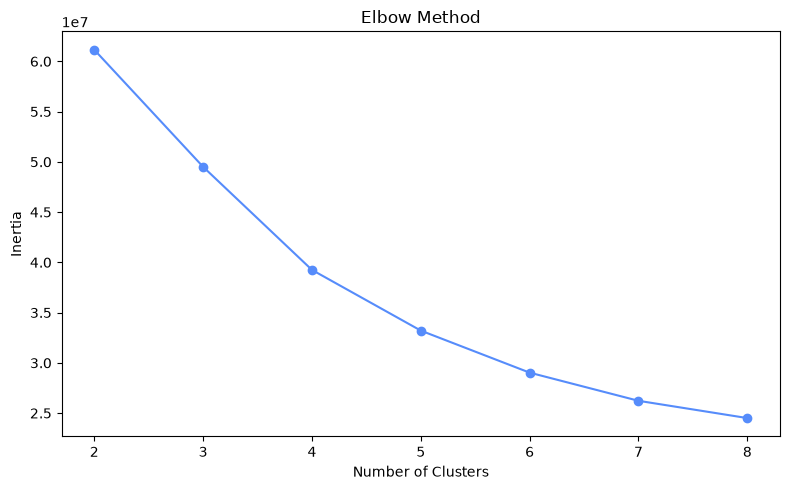

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_range),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.tight_layout()
plt.show()

#### Silhouette Score

In [13]:
sample_size = min(100_000, len(X))

rng = np.random.default_rng(42)

sample_idx = rng.choice(
    len(X),
    size=sample_size,
    replace=False
)

X_sample = X[sample_idx]

print(X_sample.shape)

(100000, 6)


In [14]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels,
        sample_size=min(100_000, len(X_sample)),
        random_state=42
    )

    silhouette_scores.append(score)

print(
    pd.DataFrame({
        "k": list(k_range),
        "silhouette_score": silhouette_scores
    })
)

   k  silhouette_score
0  2          0.327854
1  3          0.352044
2  4          0.341472
3  5          0.278728
4  6          0.281965
5  7          0.270105
6  8          0.250219


#### Silhouette Plot

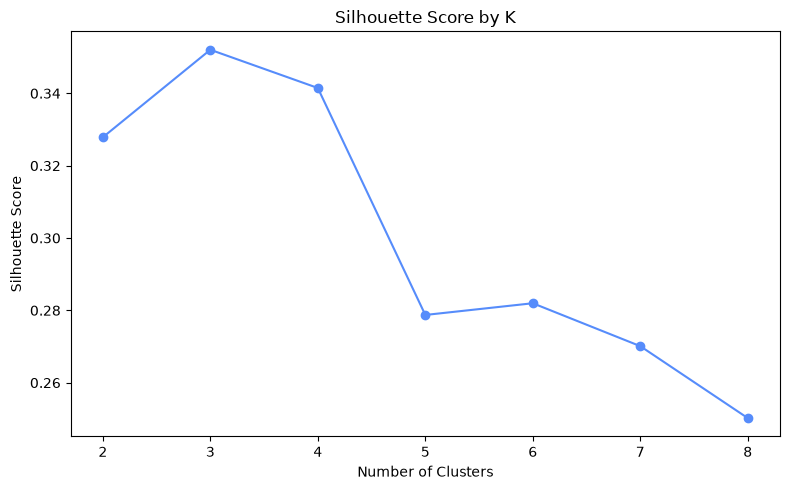

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_range),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")

plt.tight_layout()
plt.show()

#### K-Means

In [16]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

segmentation_data["cluster"] = kmeans.fit_predict(X)

print(
    segmentation_data["cluster"].value_counts().sort_index()
)

cluster
0    9181826
1    2851721
2    1622270
Name: count, dtype: int64


In [17]:
cluster_size = (
    segmentation_data["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(cluster_size)

cluster
0    67.24
1    20.88
2    11.88
Name: proportion, dtype: float64


#### PCA

In [18]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.37604818 0.26330782]
Total explained variance: 0.6393560065206968


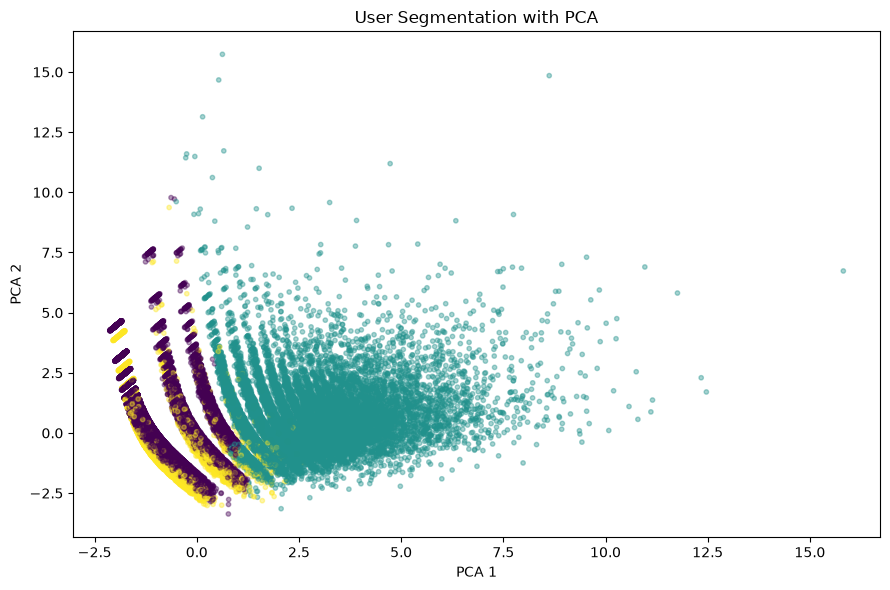

In [19]:
rng = np.random.default_rng(42)

sample_size = min(100_000, len(X_pca))

sample_idx = rng.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[sample_idx, 0],
    X_pca[sample_idx, 1],
    c=segmentation_data["cluster"].iloc[sample_idx],
    alpha=0.4,
    s=10
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("User Segmentation with PCA")

plt.tight_layout()
plt.show()

#### Cluster Profiling

In [20]:
profile = users[
    users["recommendation_count"] > 0
][
    [
        "products",
        "reviews",
        "reviews_per_product",
        "recommendation_count",
        "recommend_rate",
        "avg_hours"
    ]
].copy()

profile = profile.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

profile["cluster"] = segmentation_data["cluster"].values

cluster_profile = (
    profile
    .groupby("cluster")
    .agg(
        user_count=("cluster", "size"),
        avg_products=("products", "mean"),
        avg_reviews=("reviews", "mean"),
        avg_reviews_per_product=("reviews_per_product", "mean"),
        avg_recommendations=("recommendation_count", "mean"),
        avg_recommend_rate=("recommend_rate", "mean"),
        avg_hours=("avg_hours", "mean")
    )
    .reset_index()
)

print(cluster_profile)

   cluster  user_count  avg_products  avg_reviews  avg_reviews_per_product  \
0        0     9181826     83.300082     1.382816                 0.062916   
1        1     2851721    247.036372     9.083940                 0.084674   
2        2     1622270    104.943961     1.492717                 0.047256   

   avg_recommendations  avg_recommend_rate   avg_hours  
0             1.382816            0.994391  141.774203  
1             9.083940            0.871595   99.209374  
2             1.492717            0.148401  123.504281  


In [21]:
cluster_profile["user_ratio"] = (
    cluster_profile["user_count"] /
    cluster_profile["user_count"].sum()
)

cluster_profile["user_ratio"] = (
    cluster_profile["user_ratio"] * 100
).round(2)

print(cluster_profile)

   cluster  user_count  avg_products  avg_reviews  avg_reviews_per_product  \
0        0     9181826     83.300082     1.382816                 0.062916   
1        1     2851721    247.036372     9.083940                 0.084674   
2        2     1622270    104.943961     1.492717                 0.047256   

   avg_recommendations  avg_recommend_rate   avg_hours  user_ratio  
0             1.382816            0.994391  141.774203       67.24  
1             9.083940            0.871595   99.209374       20.88  
2             1.492717            0.148401  123.504281       11.88  


In [22]:
cluster_profile.to_csv(
    processed_dir / "user_cluster_profile.csv",
    index=False
)